# Task 2 — Data Science Component Building

This notebook covers:
1. Time difference histograms (consecutive messages, replies, reactions, events)
2. Message classification (Question / Comment / Answer / Other)
3. Topic modelling (top 10 topics per channel)
4. Sentiment analysis over time
5. MLFlow model versioning

## 0. Setup & Load Data

In [44]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
import string

from src.loader import SlackDataLoader
from src.utils import add_time_columns

loader = SlackDataLoader()
df_raw = loader.load_all_channels()
df = add_time_columns(df_raw.copy())

# Filter to actual user messages only
df = df[df['type'] == 'message'].copy()
df = df[df['text'].notna() & (df['text'].str.strip() != '')].copy()
df = df[~df['subtype'].isin(['channel_join', 'channel_leave', 'bot_message']) 
        if 'subtype' in df.columns else [True]*len(df)].copy()

print(f"Total messages: {len(df):,}")
print(f"Channels: {df['channel'].nunique()}")
print(f"Date range: {df['datetime'].min().date()} to {df['datetime'].max().date()}")

Task was destroyed but it is pending!
task: <Task pending name='Task-370' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/btsm/Desktop/P/Gebeya-Tech/gebvenv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task finished name='Task-371' coro=<Kernel.shell_main() done, defined at /Users/btsm/Desktop/P/Gebeya-Tech/gebvenv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> exception=KeyError('9459d6c1-0e41-440b-9742-525414d173f0')> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/btsm/Desktop/P/Gebeya-Tech/gebvenv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task exception was never retrieved
future: <Task finished name='Task-371' coro=<Kernel.shell_main() done, defined at /Users/btsm/Desktop/P/Gebeya-Tech/gebvenv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> exception=KeyError('9459d6c1-0e41-440b-9742-525414d173f0')>
Traceback (most recent call last):
  File "/Users/btsm/Desktop/P/Gebeya-Tech/gebvenv/lib

Total messages: 18,575
Channels: 37
Date range: 2022-08-12 to 2023-01-20


## 1. Time Difference Analysis

We analyse the distribution of time gaps between consecutive events.

In [45]:
def time_diffs_minutes(series_ts):
    """Return time differences in minutes between consecutive sorted timestamps."""
    ts = series_ts.sort_values().reset_index(drop=True)
    diffs = ts.diff().dropna().dt.total_seconds() / 60
    return diffs[diffs > 0]  # remove zero-gap duplicates


# --- Consecutive messages ---
msg_diffs = time_diffs_minutes(df['datetime'])

# --- Consecutive replies ---
# replies are messages with a 'thread_ts' different from 'ts'
replies = df[df.get('thread_ts', pd.Series(dtype='object')).notna()].copy() if 'thread_ts' in df.columns else pd.DataFrame()
if not replies.empty:
    replies = replies[replies['thread_ts'] != replies['ts']]
reply_diffs = time_diffs_minutes(replies['datetime']) if not replies.empty else pd.Series(dtype='float')

# --- Consecutive reactions ---
# reactions are stored inside each message's 'reactions' list field
reaction_rows = []
for _, row in df.iterrows():
    if isinstance(row.get('reactions'), list):
        for rxn in row['reactions']:
            reaction_rows.append({'datetime': row['datetime']})
df_reactions = pd.DataFrame(reaction_rows)
reaction_diffs = time_diffs_minutes(df_reactions['datetime']) if not df_reactions.empty else pd.Series(dtype='float')

# --- Consecutive events (message, reply, reaction) ---
all_event_ts = pd.concat([
    df['datetime'],
    replies['datetime'] if not replies.empty else pd.Series(dtype='datetime64[ns]'),
    df_reactions['datetime'] if not df_reactions.empty else pd.Series(dtype='datetime64[ns]'),
], ignore_index=True)
event_diffs = time_diffs_minutes(all_event_ts)

print(f"Consecutive message pairs:  {len(msg_diffs):,}")
print(f"Consecutive reply pairs:    {len(reply_diffs):,}")
print(f"Consecutive reaction pairs: {len(reaction_diffs):,}")
print(f"Consecutive event pairs:    {len(event_diffs):,}")

Consecutive message pairs:  18,573
Consecutive reply pairs:    8,787
Consecutive reaction pairs: 3,856
Consecutive event pairs:    18,573


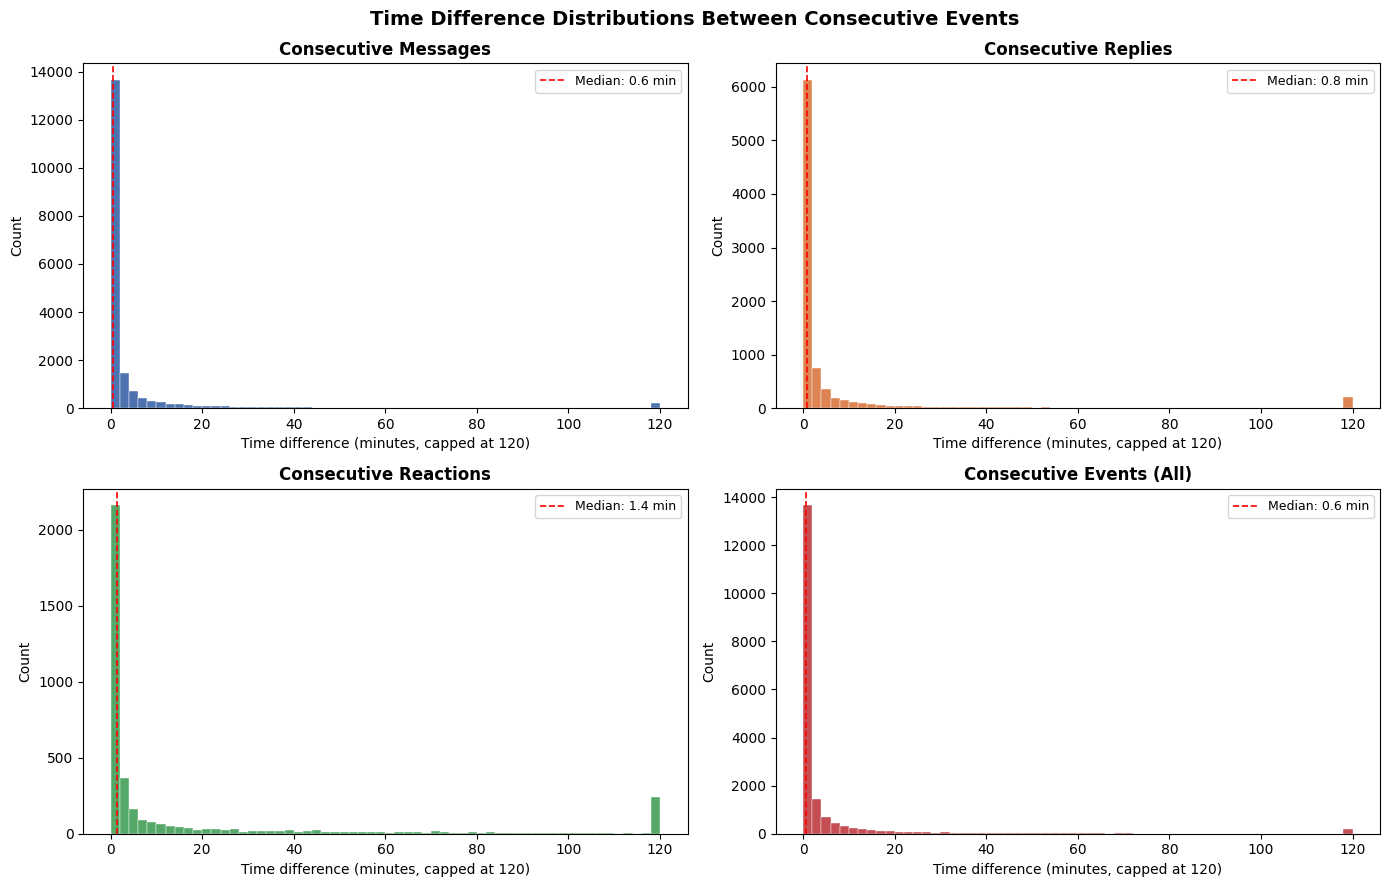

Saved: time_diff_histograms.png


In [46]:
def plot_time_diff_hist(ax, diffs, title, color, cap_minutes=120):
    """Plot a clipped histogram of time differences in minutes."""
    data = diffs.clip(upper=cap_minutes)
    ax.hist(data, bins=60, color=color, edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time difference (minutes, capped at 120)')
    ax.set_ylabel('Count')
    median_val = diffs.median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.2,
               label=f'Median: {median_val:.1f} min')
    ax.legend(fontsize=9)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Time Difference Distributions Between Consecutive Events', fontsize=14, fontweight='bold')

plot_time_diff_hist(axes[0, 0], msg_diffs, 'Consecutive Messages', '#4C72B0')
plot_time_diff_hist(axes[0, 1], reply_diffs if len(reply_diffs) > 0 else msg_diffs,
                   'Consecutive Replies', '#DD8452')
plot_time_diff_hist(axes[1, 0], reaction_diffs if len(reaction_diffs) > 0 else msg_diffs,
                   'Consecutive Reactions', '#55A868')
plot_time_diff_hist(axes[1, 1], event_diffs, 'Consecutive Events (All)', '#C44E52')

plt.tight_layout()
plt.savefig('time_diff_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: time_diff_histograms.png")

## 2. Message Classification

We classify each message into: **Question** (Technical / Non-Technical), **Comment** (Technical / Non-Technical), **Answer**, or **Other**.

Since no labeled training data exists, we use **rule-based heuristics** as a first pass — this is a common starting point before building supervised models.

In [47]:
TECH_KEYWORDS = [
    'error', 'exception', 'bug', 'code', 'function', 'class', 'module',
    'import', 'install', 'pip', 'python', 'git', 'github', 'sql', 'database',
    'api', 'json', 'csv', 'docker', 'terminal', 'command', 'library', 'package',
    'pandas', 'numpy', 'model', 'train', 'dataset', 'jupyter', 'notebook',
    'variable', 'loop', 'list', 'dict', 'array', 'file', 'path', 'run',
    'output', 'input', 'debug', 'syntax', 'attribute', 'method', 'object'
]

QUESTION_PATTERNS = [
    r'\?',
    r'\b(how|what|why|when|where|who|which|can|could|would|should|does|is|are|was|were|do|did)\b'
]

ANSWER_PATTERNS = [
    r'^(yes|no|sure|correct|exactly|right|yep|nope|indeed|absolutely)\b',
    r'\b(you (can|should|need to|have to)|try|the (answer|solution|fix) is|you just|here is|here\'s)\b'
]


def is_question(text):
    t = text.lower()
    return any(re.search(p, t) for p in QUESTION_PATTERNS)


def is_answer(text):
    t = text.lower()
    return any(re.search(p, t) for p in ANSWER_PATTERNS)


def is_technical(text):
    t = text.lower()
    return any(kw in t for kw in TECH_KEYWORDS)


def classify_message(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'Other'
    tech = is_technical(text)
    if is_question(text):
        return 'Question-Technical' if tech else 'Question-NonTechnical'
    if is_answer(text):
        return 'Answer'
    if tech:
        return 'Comment-Technical'
    return 'Comment-NonTechnical'


df['message_type'] = df['text'].apply(classify_message)

type_counts = df['message_type'].value_counts()
print(type_counts)
print(f"\nTotal classified: {len(df):,}")

message_type
Comment-NonTechnical     8631
Question-NonTechnical    6502
Question-Technical       1718
Comment-Technical        1027
Answer                    697
Name: count, dtype: int64

Total classified: 18,575


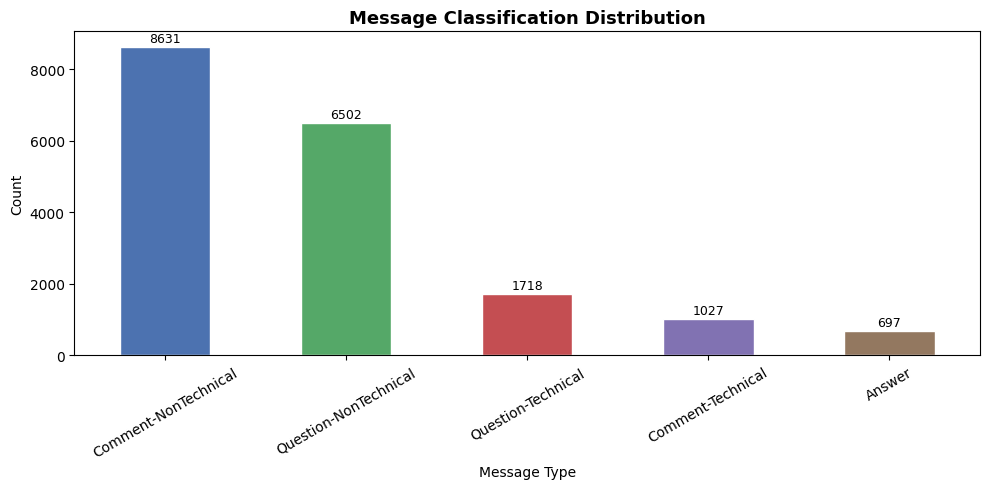

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
type_counts.plot(kind='bar', ax=ax, color=colors[:len(type_counts)], edgecolor='white')
ax.set_title('Message Classification Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Message Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(type_counts):
    ax.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('message_classification.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Topic Modelling (LDA)

We use **Latent Dirichlet Allocation (LDA)** to find the top 10 topics across all channels.

In [49]:
import ssl
import nltk
import string
from collections import Counter
from itertools import combinations

print("Script: task2_analysis.ipynb — Advanced LDA Section")

try:
    ssl._create_default_https_context = ssl._create_unverified_context
except AttributeError:
    pass
nltk.download('stopwords', quiet=True)
nltk.download('names', quiet=True)

from nltk.corpus import stopwords, names
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

NLTK_STOPS = set(stopwords.words('english'))
CUSTOM_STOPS = {
    'hello', 'hey', 'guys', 'okay', 'yeah', 'man', 'grin', 'grinning',
    'rolling', 'laughing', 'think', 'like', 'sure', 'well', 'mean', 'guess',
    'might', 'would', 'could', 'got', 'get', 'let', 'one', 'two', 'hi',
    'lol', 'haha', 'also', 'really', 'everyone', 'great', 'need', 'know',
    'dont', 'cant', 'lets', 'want', 'come', 'run', 'new', 'right', 'going',
    'nice', 'take', 'even', 'still', 'back', 'much', 'better', 'first',
    # added
    'lie', 'yes', 'thats', 'didnt', 'far', 'anyone',
}
ALL_STOPS = NLTK_STOPS | CUSTOM_STOPS
FIRST_NAMES = set(n.lower() for n in names.words())

print(f"Stopword list size: {len(ALL_STOPS)} words")
print(f"First names to filter: {len(FIRST_NAMES):,}")

def preprocess(text):
    if not isinstance(text, str):
        return []
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'<@[A-Za-z0-9]+>', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r':[a-z_]+:', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.lower()
    return [
        t for t in text.split()
        if t not in ALL_STOPS
        and t not in FIRST_NAMES
        and len(t) >= 3
    ]

df['tokens'] = df['text'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda t: ' '.join(t))

print(f"\nTokenized {len(df):,} messages")
print(f"Sample tokens: {df[df['tokens'].apply(len) > 0]['tokens'].iloc[0][:12]}")

Script: task2_analysis.ipynb — Advanced LDA Section
Stopword list size: 254 words
First names to filter: 7,576

Tokenized 18,575 messages
Sample tokens: ['meeting', 'started']


In [50]:
# ── BIGRAMS (shared by both runs) ────────────────────────────────────────────
print("Building bigrams...")
unigram_counts = Counter()
bigram_counts = Counter()
for tokens in df['tokens']:
    unigram_counts.update(tokens)
    for i in range(len(tokens) - 1):
        bigram_counts[(tokens[i], tokens[i+1])] += 1

total_words = sum(unigram_counts.values())
valid_bigrams = set()
for (w1, w2), count in bigram_counts.items():
    if count >= 5:
        score = (count * total_words) / (unigram_counts[w1] * unigram_counts[w2])
        if score >= 10:
            valid_bigrams.add((w1, w2))
print(f"Valid bigrams: {len(valid_bigrams)}")

def apply_bigrams(tokens):
    result, i = [], 0
    while i < len(tokens):
        if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) in valid_bigrams:
            result.append(f"{tokens[i]}_{tokens[i+1]}")
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    return result

df['tokens_bigram'] = df['tokens'].apply(apply_bigrams)

# ── channel_counts — computed here so this cell is self-contained ─────────────
channel_counts = df.groupby('channel').size().sort_values(ascending=False)

# ── HELPERS ───────────────────────────────────────────────────────────────────
def build_dtm(token_series, max_features=3000):
    docs = token_series.apply(lambda t: ' '.join(t))
    docs = docs[docs.str.strip() != ''].tolist()
    vec = CountVectorizer(max_df=0.95, min_df=5, max_features=max_features)
    dtm = vec.fit_transform(docs)
    return dtm, vec, docs

def cv_coherence(lda_model, dtm, top_n=10):
    n_docs = dtm.shape[0]
    dtm_bool = (dtm > 0).toarray()
    scores = []
    for topic in lda_model.components_:
        top_idx = topic.argsort()[:-top_n-1:-1]
        topic_score, count = 0.0, 0
        for i, j in combinations(top_idx, 2):
            p_i  = dtm_bool[:, i].sum() / n_docs
            p_j  = dtm_bool[:, j].sum() / n_docs
            p_ij = (dtm_bool[:, i] & dtm_bool[:, j]).sum() / n_docs
            if p_ij > 0 and p_i > 0 and p_j > 0:
                npmi = np.log(p_ij / (p_i * p_j)) / -np.log(p_ij)
                topic_score += npmi
                count += 1
        scores.append(topic_score / count if count > 0 else 0)
    return np.mean(scores)

def run_lda_search(token_series, label, k_values=[9, 10, 11, 12]):
    dtm, vec, docs = build_dtm(token_series)
    feat = vec.get_feature_names_out()
    print(f"\n── {label} ({len(docs):,} docs, {dtm.shape[1]:,} terms) ──")
    print(f"  {'k':>4}  {'CV Coherence':>14}")
    print(f"  {'─'*22}")
    best_k, best_score, best_lda = None, -np.inf, None
    for k in k_values:
        lda_k = LatentDirichletAllocation(
            n_components=k, random_state=42, max_iter=40, learning_method='batch'
        )
        lda_k.fit(dtm)
        score = cv_coherence(lda_k, dtm)
        print(f"  {k:>4}  {score:>14.6f}")
        if score > best_score:
            best_score, best_k, best_lda = score, k, lda_k
    print(f"  → Best k={best_k}  score={best_score:.6f}")
    return best_lda, dtm, vec, feat, best_k, best_score

# ── RUN 1: ALL MESSAGES ───────────────────────────────────────────────────────
lda_all, dtm_all, vec_all, feat_all, k_all, score_all = run_lda_search(
    df['tokens_bigram'], label="Run 1 — All messages"
)

# ── RUN 2: FILTERED — technical/announcement channels with >500 messages ──────
TECH_KEYWORDS = ['week', 'technical', 'data', 'machine', 'broadcast',
                 'career', 'community', 'resources', 'kafka', 'dsa', 'engineering']
tech_channels = [
    ch for ch, cnt in channel_counts.items()
    if cnt > 500 and any(kw in ch for kw in TECH_KEYWORDS)
]
print(f"\nFiltered channels ({len(tech_channels)} channels with >500 msgs):")
for ch in tech_channels:
    print(f"  {ch}  ({channel_counts[ch]} messages)")

df_filtered = df[df['channel'].isin(tech_channels)]
lda_filt, dtm_filt, vec_filt, feat_filt, k_filt, score_filt = run_lda_search(
    df_filtered['tokens_bigram'], label="Run 2 — Filtered corpus"
)

# ── COMPARISON ────────────────────────────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"  {'Run':<30} {'Best k':>6}  {'CV Score':>10}")
print(f"  {'─'*43}")
print(f"  {'All messages':<30} {k_all:>6}  {score_all:>10.6f}")
print(f"  {'Filtered (tech/announcement)':<30} {k_filt:>6}  {score_filt:>10.6f}")
target = 0.45
print(f"\n  Target: {target:.2f}  |  Gap: {target - max(score_all, score_filt):.6f}")

# Expose best model for cell-12
if score_filt >= score_all:
    lda, dtm_final, feature_names, vectorizer, N_TOPICS = lda_filt, dtm_filt, feat_filt, vec_filt, k_filt
    print(f"\n  → Using filtered corpus for final model (k={k_filt})")
else:
    lda, dtm_final, feature_names, vectorizer, N_TOPICS = lda_all, dtm_all, feat_all, vec_all, k_all
    print(f"\n  → Using all-messages corpus for final model (k={k_all})")

doc_term_matrix = dtm_final

Building bigrams...
Valid bigrams: 718

── Run 1 — All messages (14,453 docs, 2,828 terms) ──
     k    CV Coherence
  ──────────────────────
     9        0.137643
    10        0.203396
    11        0.187554
    12        0.233353
  → Best k=12  score=0.233353

Filtered channels (6 channels with >500 msgs):
  all-community-building  (8071 messages)
  all-resources  (1463 messages)
  kafka_de  (936 messages)
  all-career-exercises  (801 messages)
  all-week1  (573 messages)
  all-broadcast  (555 messages)

── Run 2 — Filtered corpus (9,175 docs, 1,888 terms) ──
     k    CV Coherence
  ──────────────────────
     9        0.255754
    10        0.364618
    11        0.255205
    12        0.264169
  → Best k=10  score=0.364618

─────────────────────────────────────────────
  Run                            Best k    CV Score
  ───────────────────────────────────────────
  All messages                       12    0.233353
  Filtered (tech/announcement)       10    0.364618

  Target: 

In [31]:
# --- Bigrams ---
print("Building bigrams...")
unigram_counts = Counter()
bigram_counts = Counter()

for tokens in df['tokens']:
    unigram_counts.update(tokens)
    for i in range(len(tokens) - 1):
        bigram_counts[(tokens[i], tokens[i+1])] += 1

total_words = sum(unigram_counts.values())
valid_bigrams = set()
for (w1, w2), count in bigram_counts.items():
    if count >= 5:
        score = (count * total_words) / (unigram_counts[w1] * unigram_counts[w2])
        if score >= 10:
            valid_bigrams.add((w1, w2))

print(f"Valid bigrams: {len(valid_bigrams)}")

def apply_bigrams(tokens):
    result, i = [], 0
    while i < len(tokens):
        if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) in valid_bigrams:
            result.append(f"{tokens[i]}_{tokens[i+1]}")
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    return result

df['tokens_bigram'] = df['tokens'].apply(apply_bigrams)
corpus_docs = df['tokens_bigram'].apply(lambda t: ' '.join(t))
corpus_docs = corpus_docs[corpus_docs.str.strip() != ''].tolist()
print(f"Corpus: {len(corpus_docs):,} documents")

# --- Vectorize ---
vectorizer = CountVectorizer(max_df=0.95, min_df=5, max_features=3000)
dtm = vectorizer.fit_transform(corpus_docs)
feature_names = vectorizer.get_feature_names_out()
print(f"Vocabulary: {len(feature_names):,} terms\n")

# --- CV Coherence via NPMI (no gensim needed) ---
# NPMI(wi, wj) = log(P(wi,wj) / P(wi)*P(wj)) / -log(P(wi,wj))
# Higher is better (range -1 to 1). Approximates gensim's c_v metric.
n_docs = dtm.shape[0]
dtm_bool = (dtm > 0).toarray()

def cv_coherence(lda_model, top_n=10):
    scores = []
    for topic in lda_model.components_:
        top_idx = topic.argsort()[:-top_n-1:-1]
        topic_score, count = 0.0, 0
        for i, j in combinations(top_idx, 2):
            p_i   = dtm_bool[:, i].sum() / n_docs
            p_j   = dtm_bool[:, j].sum() / n_docs
            p_ij  = (dtm_bool[:, i] & dtm_bool[:, j]).sum() / n_docs
            if p_ij > 0 and p_i > 0 and p_j > 0:
                npmi = np.log(p_ij / (p_i * p_j)) / -np.log(p_ij)
                topic_score += npmi
                count += 1
        scores.append(topic_score / count if count > 0 else 0)
    return np.mean(scores)

# --- Coherence search: k = 9, 10, 11, 12 ---
K_VALUES = [9, 10, 11, 12]
print(f"{'k':>4}  {'CV Coherence (NPMI)':>22}")
print("-" * 30)

results = {}
best_k, best_score, best_lda = None, -np.inf, None
for k in K_VALUES:
    lda_k = LatentDirichletAllocation(
        n_components=k, random_state=42, max_iter=40, learning_method='batch'
    )
    lda_k.fit(dtm)
    score = cv_coherence(lda_k)
    results[k] = score
    print(f"{k:>4}  {score:>22.6f}")
    if score > best_score:
        best_score, best_k, best_lda = score, k, lda_k

print(f"\nBest k = {best_k}  (CV coherence = {best_score:.6f})")
N_TOPICS = best_k
lda = best_lda
doc_term_matrix = dtm

Building bigrams...
Valid bigrams: 718
Corpus: 14,453 documents
Vocabulary: 2,828 terms

   k     CV Coherence (NPMI)
------------------------------
   9                0.137643
  10                0.203396
  11                0.187554
  12                0.233353

Best k = 12  (CV coherence = 0.233353)


Top 10 words per topic (k=12):

  Topic  1: task, check, use, birthday, number, reminder_todays, standup_start, meeting_link, joannemin_join, running
  Topic  2: session, meet, time_utc, time_platform, login_starting, minutes, day, please, next_session, please_note
  Topic  3: data, ready, name, model, part, use, file, test, tell, different
  Topic  4: good, high, low, file, already, tried, point, find, line, dvc
  Topic  5: thank, try, repo, meeting, create, problem, week, work, created, give
  Topic  6: thanks, work, people, team, many, game, hard, yesterday, call, make
  Topic  7: help, please, next, sorry, keep, exactly, morning, community_building, please_note, cbs_next
  Topic  8: install, airflow, installed, read, share, start, docker, worked, answer, started
  Topic  9: today, using, error, thought, cbs, issue, use, used, academy, join
  Topic 10: link, good_morning, use, channel, bro, send, something, week, report, email
  Topic 11: group, done, working, life, access, every, t

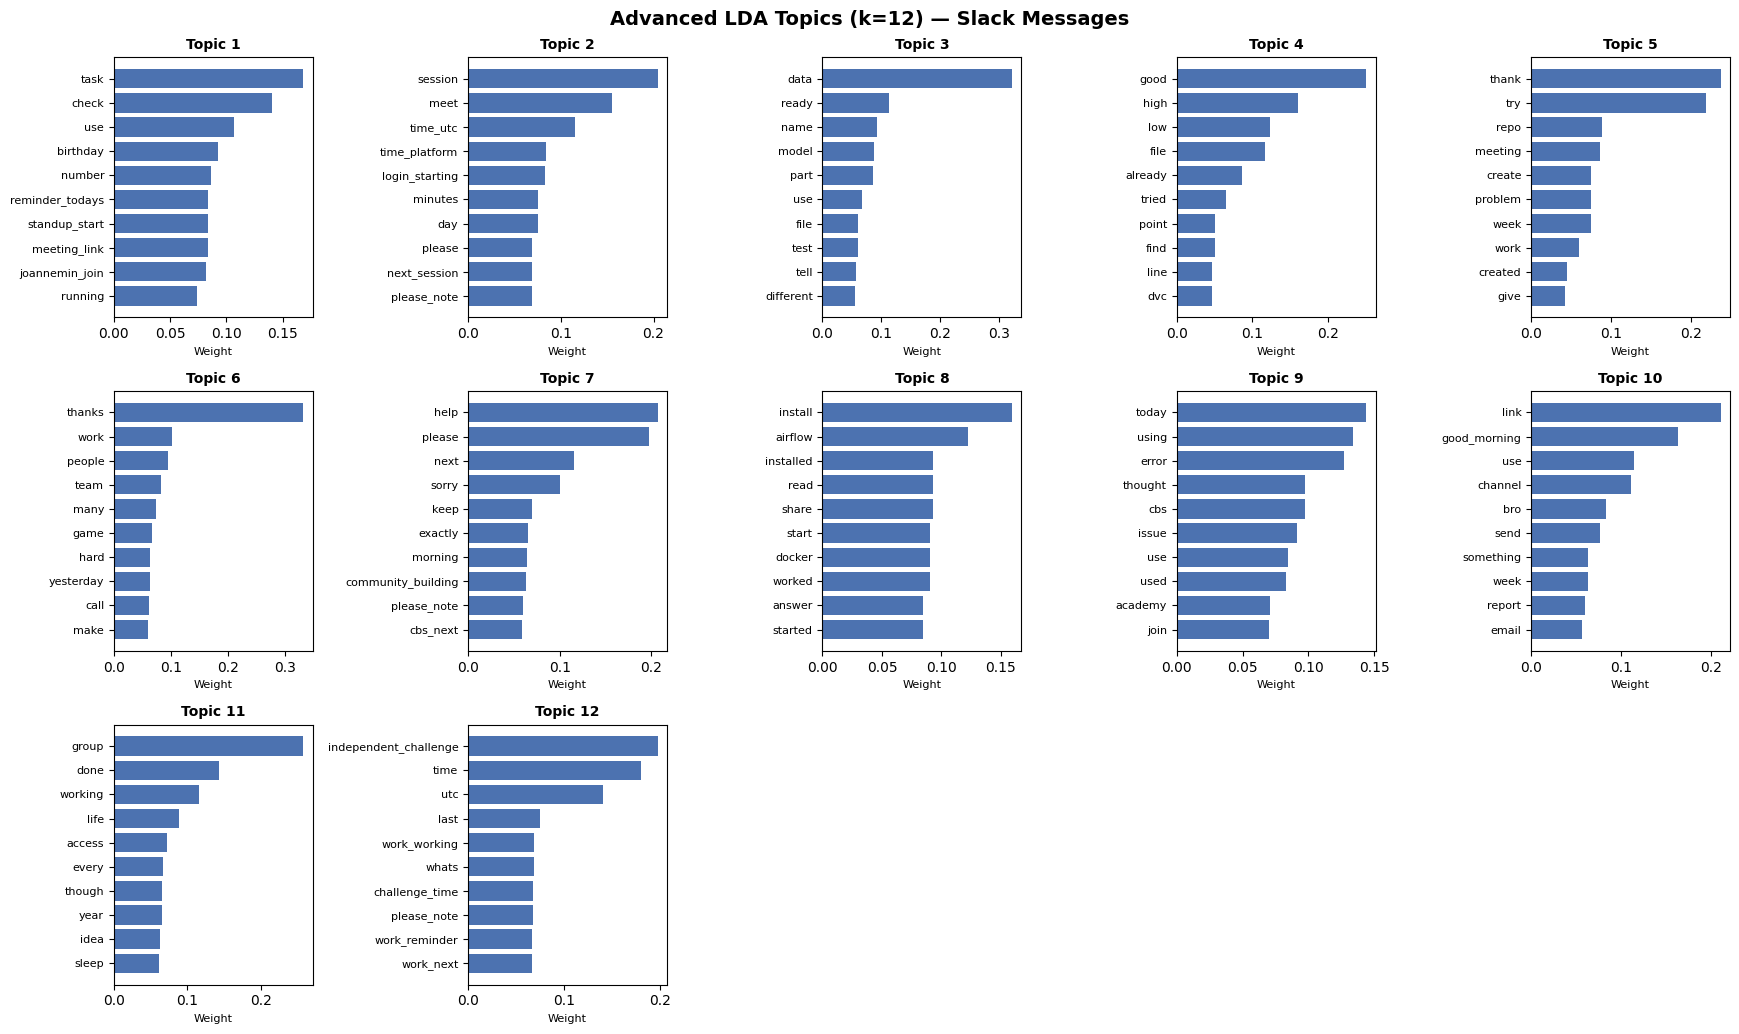

Saved: topic_modelling_advanced.png


In [32]:
# Print topics first — verify preprocessing before plotting
print(f"Top 10 words per topic (k={N_TOPICS}):\n")
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    print(f"  Topic {i+1:2d}: {', '.join(top_words)}")

# Plot
cols = min(N_TOPICS, 5)
rows = (N_TOPICS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
axes = axes.flatten() if N_TOPICS > 1 else [axes]
fig.suptitle(f'Advanced LDA Topics (k={N_TOPICS}) — Slack Messages', fontsize=14, fontweight='bold')

for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[:-11:-1]
    top_words = [feature_names[j] for j in top_idx]
    top_weights = topic[top_idx]
    top_weights = top_weights / top_weights.sum()
    axes[i].barh(top_words[::-1], top_weights[::-1], color='#4C72B0')
    axes[i].set_title(f'Topic {i+1}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Weight', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

for ax in axes[N_TOPICS:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('topic_modelling_advanced.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: topic_modelling_advanced.png")

## 4. Sentiment Analysis Over Time

We group messages by **day since training start** and measure sentiment using **TextBlob**.
Sentiment polarity ranges from -1 (negative) to +1 (positive).

In [33]:
from textblob import TextBlob

# Training start = earliest message date in the dataset
training_start = df['datetime'].min().normalize()
df['days_since_start'] = (df['datetime'].dt.normalize() - training_start).dt.days

print(f"Training start: {training_start.date()}")
print(f"Total days in dataset: {df['days_since_start'].max()}")

Training start: 2022-08-12
Total days in dataset: 161


In [34]:
# Group by day — concatenate all messages into one big text per day
daily_texts = df.groupby('days_since_start')['clean_text'].apply(
    lambda texts: ' '.join(texts.dropna())
).reset_index()
daily_texts.columns = ['days_since_start', 'combined_text']

# Compute sentiment polarity for each day
daily_texts['sentiment'] = daily_texts['combined_text'].apply(
    lambda t: TextBlob(t).sentiment.polarity if t.strip() else 0
)

print(f"Days analysed: {len(daily_texts)}")
print(f"Mean sentiment: {daily_texts['sentiment'].mean():.3f}")
print(f"Min sentiment:  {daily_texts['sentiment'].min():.3f}")
print(f"Max sentiment:  {daily_texts['sentiment'].max():.3f}")

Days analysed: 102
Mean sentiment: 0.150
Min sentiment:  -0.046
Max sentiment:  0.600


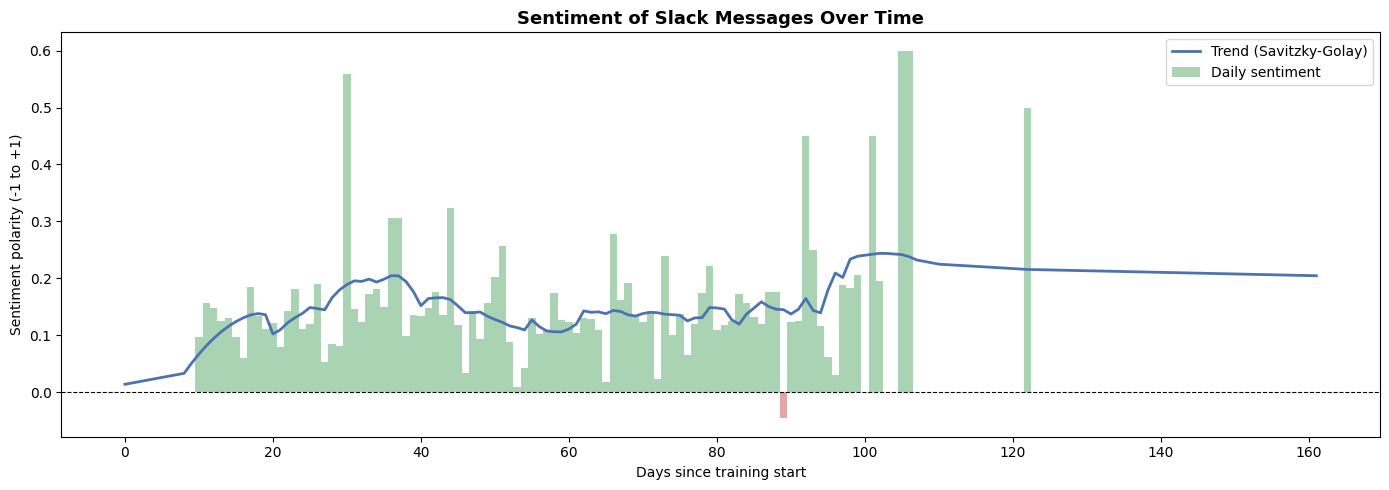


Overall sentiment is positive (mean polarity = 0.150).


In [35]:
from scipy.signal import savgol_filter

fig, ax = plt.subplots(figsize=(14, 5))

x = daily_texts['days_since_start']
y = daily_texts['sentiment']

ax.bar(x, y, color=np.where(y >= 0, '#55A868', '#C44E52'), alpha=0.5, width=1, label='Daily sentiment')

# Smoothed trend line (only if enough data points)
if len(y) >= 11:
    window = min(21, len(y) if len(y) % 2 != 0 else len(y) - 1)
    if window >= 5:
        smoothed = savgol_filter(y, window_length=window, polyorder=2)
        ax.plot(x, smoothed, color='#4C72B0', linewidth=2, label='Trend (Savitzky-Golay)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Sentiment of Slack Messages Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Days since training start')
ax.set_ylabel('Sentiment polarity (-1 to +1)')
ax.legend()
plt.tight_layout()
plt.savefig('sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Commentary
mean_s = y.mean()
trend = 'positive' if mean_s > 0.05 else 'negative' if mean_s < -0.05 else 'neutral'
print(f"\nOverall sentiment is {trend} (mean polarity = {mean_s:.3f}).")

## 5. MLFlow — Version ML Models & Artefacts

MLFlow tracks experiments: parameters, metrics, and model artefacts. We log the LDA model and the vectorizer here.

In [36]:
import mlflow
import mlflow.sklearn
import pickle
import os

# Store MLFlow runs in a local directory
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('slack-analysis-task2')

with mlflow.start_run(run_name='lda-topic-model'):
    # Log parameters
    mlflow.log_param('n_topics', N_TOPICS)
    mlflow.log_param('max_iter', 20)
    mlflow.log_param('vocab_size', len(feature_names))
    mlflow.log_param('corpus_size', len(corpus))

    # Log metrics
    mlflow.log_metric('perplexity', lda.perplexity(doc_term_matrix))
    mlflow.log_metric('mean_sentiment', float(daily_texts['sentiment'].mean()))

    # Log the LDA model
    mlflow.sklearn.log_model(lda, artifact_path='lda_model')

    # Log the vectorizer as a pickle artefact
    vec_path = '/tmp/vectorizer.pkl'
    with open(vec_path, 'wb') as f:
        pickle.dump(vectorizer, f)
    mlflow.log_artifact(vec_path, artifact_path='vectorizer')

    # Log charts as artefacts
    for chart in ['time_diff_histograms.png', 'message_classification.png',
                  'topic_modelling.png', 'sentiment_over_time.png']:
        if os.path.exists(chart):
            mlflow.log_artifact(chart, artifact_path='charts')

    run_id = mlflow.active_run().info.run_id

print(f"MLFlow run logged. Run ID: {run_id}")
print("To view the UI, run: mlflow ui  (then open http://localhost:5000)")

2026/06/03 16:52:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 16:52:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 16:52:21 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


MLFlow run logged. Run ID: f6a9fc0d8a65455aa6884b8553964c03
To view the UI, run: mlflow ui  (then open http://localhost:5000)


## Summary of MLOps Components

| Component | What it does | Tool used |
|---|---|---|
| **Experiment Tracking** | Logs parameters, metrics, and model artefacts for every run | MLFlow |
| **Feature Store** | Central storage for ML features (e.g. TF-IDF vectors) | PostgreSQL (Task 3) |
| **Model Versioning** | Tags each model with a version and stage (Staging/Production) | MLFlow Model Registry |
| **Model Monitoring** | Detects when a deployed model degrades (data drift, accuracy drop) | MLwatcher / custom |
| **CI/CD Pipeline** | Automatically tests and packages code on every push | GitHub Actions |
| **Containerisation** | Packages app + dependencies into a portable image | Docker (Task 5) |

In this task we use MLFlow for experiment tracking and model versioning. The LDA topic model and the TF-IDF vectorizer are saved as artefacts so they can be reproduced or re-loaded later.